In [1]:
## MPLEMENTATION


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns


Dataset (Breast Cancer Wisconsin)

In [3]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)


Data Splitting Train/Test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


Standardization unifying values

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Calculating the imbalance ratio

In [9]:
from collections import Counter
print("Class Distribution:", Counter(y_train))


Class Distribution: Counter({1: 285, 0: 170})


Model 1: Baseline XGBoost (No processing)

In [10]:
baseline_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)


Model 2: SMOTE + XGBoost

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

smote_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

smote_model.fit(X_train_sm, y_train_sm)
y_pred_smote = smote_model.predict(X_test)


Model 3: Cost-Sensitive XGBoost

Calculating the class weight:




In [12]:
majority = sum(y_train == 0)
minority = sum(y_train == 1)
scale_pos_weight = majority / minority
scale_pos_weight


0.5964912280701754

We apply the model:

In [14]:
cost_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

cost_model.fit(X_train, y_train)
y_pred_cost = cost_model.predict(X_test)


Model 4 (FINAL PROPOSED): Hybrid (SMOTE + Cost-Sensitive XGBoost)

In [15]:
hybrid_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

hybrid_model.fit(X_train_sm, y_train_sm)
y_pred_hybrid = hybrid_model.predict(X_test)


Performance Evaluation (Precision, Recall, F1, AUC)

In [16]:
def evaluate_model(y_true, y_pred, name):
    print(f"\n===== {name} =====")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

print("Baseline Model")
evaluate_model(y_test, y_pred_baseline, "Baseline")

print("SMOTE Model")
evaluate_model(y_test, y_pred_smote, "SMOTE")

print("Cost-Sensitive Model")
evaluate_model(y_test, y_pred_cost, "Cost-Sensitive")

print("Hybrid Model")
evaluate_model(y_test, y_pred_hybrid, "Hybrid")


Baseline Model

===== Baseline =====
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
[[38  4]
 [ 1 71]]
SMOTE Model

===== SMOTE =====
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion Matrix:
[[39  3]
 [ 3 69]]
Cost-Sensitive Model

===== Cost-Sensitive =====
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97   

ROC Curve Comparison

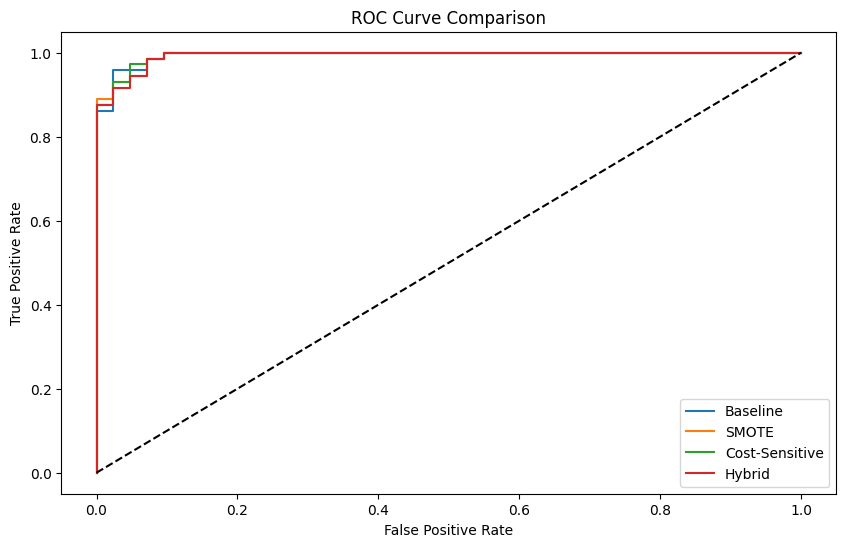

In [17]:
plt.figure(figsize=(10,6))

models = {
    "Baseline": baseline_model,
    "SMOTE": smote_model,
    "Cost-Sensitive": cost_model,
    "Hybrid": hybrid_model
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


Recall comparison between each model

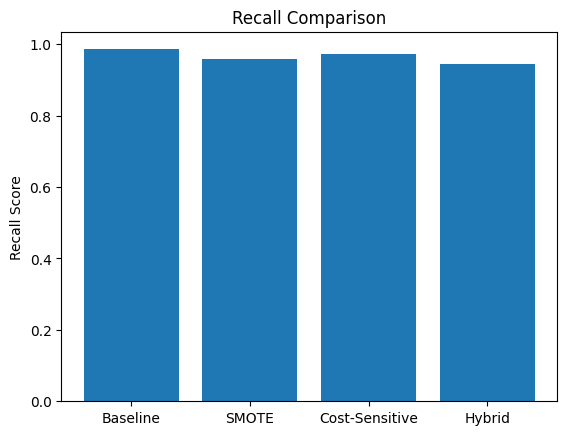

In [18]:
from sklearn.metrics import recall_score

recalls = {
    "Baseline": recall_score(y_test, y_pred_baseline),
    "SMOTE": recall_score(y_test, y_pred_smote),
    "Cost-Sensitive": recall_score(y_test, y_pred_cost),
    "Hybrid": recall_score(y_test, y_pred_hybrid)
}

plt.bar(recalls.keys(), recalls.values())
plt.title("Recall Comparison")
plt.ylabel("Recall Score")
plt.show()


Final comparison table

In [19]:
import pandas as pd
from sklearn.metrics import precision_score, f1_score

results = pd.DataFrame({
    "Model": ["Baseline","SMOTE","Cost-Sensitive","Hybrid"],
    "Recall": [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_cost),
        recall_score(y_test, y_pred_hybrid)
    ],
    "Precision": [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_cost),
        precision_score(y_test, y_pred_hybrid)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_cost),
        f1_score(y_test, y_pred_hybrid)
    ]
})

results


,Model,Recall,Precision,F1-Score
0,Baseline,0.986111,0.946667,0.965986
1,SMOTE,0.958333,0.958333,0.958333
2,Cost-Sensitive,0.972222,0.958904,0.965517
3,Hybrid,0.944444,0.971429,0.957746


New additions (optional to the code)

Confusion Matrix drawing for each model

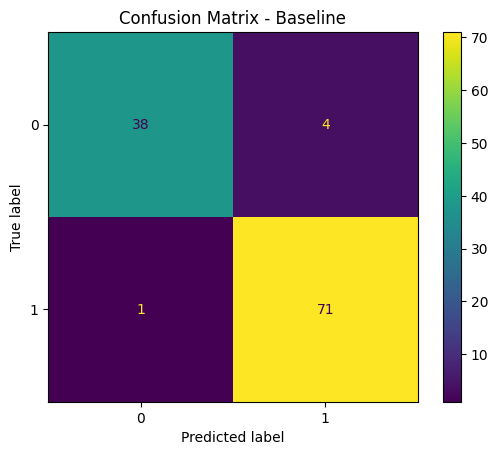

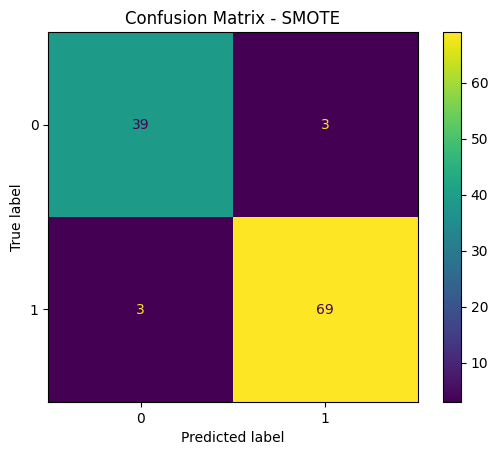

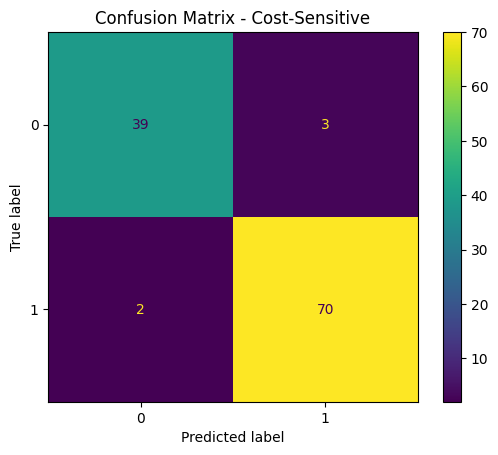

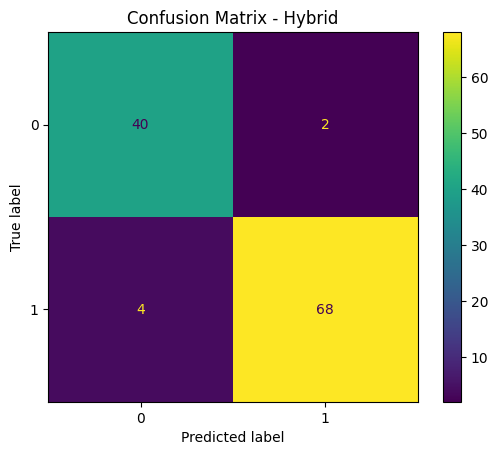

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

models_preds = {
    "Baseline": y_pred_baseline,
    "SMOTE": y_pred_smote,
    "Cost-Sensitive": y_pred_cost,
    "Hybrid": y_pred_hybrid
}

for name, preds in models_preds.items():
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, preds))
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


Extracting the False Negative number for each model



In [21]:
from sklearn.metrics import confusion_matrix

def get_fn(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn

print("FN - Baseline:", get_fn(y_test, y_pred_baseline))
print("FN - SMOTE:", get_fn(y_test, y_pred_smote))
print("FN - Cost-Sensitive:", get_fn(y_test, y_pred_cost))
print("FN - Hybrid:", get_fn(y_test, y_pred_hybrid))


FN - Baseline: 1
FN - SMOTE: 3
FN - Cost-Sensitive: 2
FN - Hybrid: 4
